In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
import random

l = [0,1,2,3,4,5,6,7,8,9,10]
random.seed(42)
random.sample(l,3)

[10, 1, 0]

# Phase 1


In [2]:
# Test in a notebook or Python script
import pandas as pd
from grid_material_mapping import load_grid_material_mapping
from tree_species import TreeSpeciesDatabase

# Test baseline_materials.csv
baseline = pd.read_csv('grid_records/baseline_materials.csv')
print(f"Loaded {len(baseline)} material records")
print(f"Ground surfaces: {(baseline['ground_or_facade'] == 'ground').sum()}")
print(f"Facade surfaces: {(baseline['ground_or_facade'] == 'facade').sum()}")

# Test tree species database
species_db = TreeSpeciesDatabase()
species_db.load_from_csv('tree_species_database.csv')
print(f"Loaded {len(species_db.species_dict)} species")

Loaded 233 material records
Ground surfaces: 72
Facade surfaces: 161
Loaded 33 species


# Phase 2

In [7]:
import os
import sys
from material_scenario_workflow import MaterialScenarioWorkflow
import numpy as np
import sys

if sys.platform=="win32":
    windows=True
    user_folder = r"c:\\Users\\Justin"
else:
    windows=False
    user_folder = '/Users/jmccarty'

# Configure paths
PROJECT_ROOT = os.path.join(user_folder, 'Nextcloud','Projects','35_UHI_Trees_Manitoba')
JODLA_DIR = os.path.join(PROJECT_ROOT, '00_data_code', 'jodla_project')

# Create the 25 scenarios
predefined_scenarios = []
for x in np.arange(0,1.1,0.25):
    for y in np.arange(0,1.1,0.25):
        predefined_scenarios.append((x,y))

# Initialize workflow
# Note: root_material_database.csv, base_material_library.txt, and tree_species_database.csv
# are automatically loaded from the jodla_project directory
workflow = MaterialScenarioWorkflow(
    baseline_project_dir=os.path.join(JODLA_DIR, 'python','baseline_radiance_project'),
    scenario_project_dir=os.path.join(JODLA_DIR, 'python','scenario_radiance_project'),
    tree_points_file=os.path.join(JODLA_DIR, 'grid_records','baseline_trees.csv'),
    sensor_points_file=None,  # Will extract from feather columns
    weather_file=os.path.join(JODLA_DIR, 'weather.epw'),
    scenario_instructions=predefined_scenarios
)


   Loaded grid-material mapping: baseline=True, scenarios=True


In [8]:
print("🚀 Starting baseline raytracing...")
print(f"   Project: {workflow.baseline_project_dir}")
print(f"   Output: {workflow.raytracing_results_dir}")

# Run baseline raytracing
# This will generate baseline_direct.feather and baseline_diffuse.feather
# Set use_accelerad=True to use GPU-accelerated Accelerad (faster)
baseline_direct, baseline_diffuse = workflow.run_baseline_raytracing(
    n_workers=6,
    use_accelerad=True  # Set to True if Accelerad is installed
)

print("\n✅ Baseline raytracing complete!")
print(f"   Direct irradiance saved to: {baseline_direct}")
print(f"   Diffuse irradiance saved to: {baseline_diffuse}")

🚀 Starting baseline raytracing...
   Project: /Users/jmccarty/Nextcloud/Projects/35_UHI_Trees_Manitoba/00_data_code/jodla_project/python/baseline_radiance_project
   Output: /Users/jmccarty/Nextcloud/Projects/35_UHI_Trees_Manitoba/00_data_code/jodla_project/raytracing_results
BASELINE RAYTRACING

1. Setting up material database...

2. Generating baseline feather files...
   Running 2-phase DDS simulation (use_accelerad=True)...
 - Running 2-Phase DDS with 6 workers
 - Current surface is (root)
 - Initializing the weather file.
     - Filtered WEA: 4656 daylight hours (from 8760 total hours)
     - Weather file initialized in 0.29 seconds
 - Starting Part 1 (total).
     - oconv


oconv: system - cannot open scene file "/var/folders/ww/12z6q0wj4c527ftkk7sxqb680000gp/T/baseline_temp_1gt51obr/baseline/scene/envelope.mat": No such file or directory


RuntimeError: An error occurred with exit code 2: 

In [ ]:

# Quick check of the data
import pandas as pd
df_direct = pd.read_feather("/Users/jmccarty/Nextcloud/Projects/35_UHI_Trees_Manitoba/00_data_code/jodla_project/raytracing_results/baseline_direct.feather")
df_diffuse = pd.read_feather("/Users/jmccarty/Nextcloud/Projects/35_UHI_Trees_Manitoba/00_data_code/jodla_project/raytracing_results/baseline_diffuse.feather")

print(f"\n📊 Data summary:")
print(f"   Timesteps: {len(df_direct)}")
print(f"   Grid points: {len(df_direct.columns) - 1}")  # -1 for datetime column


📊 Data summary:
   Timesteps: 42197
   Grid points: 8759


KeyError: 'datetime'

In [ ]:
# Optional: List existing feather files to verify simulations ran
import os
import glob

raytracing_dir = workflow.raytracing_results_dir
print(f"📁 Checking feather files in: {raytracing_dir}\n")

# Check baseline
baseline_direct = os.path.join(raytracing_dir, 'baseline_direct.feather')
baseline_diffuse = os.path.join(raytracing_dir, 'baseline_diffuse.feather')
print(f"Baseline files:")
print(f"   Direct:  {'✅' if os.path.exists(baseline_direct) else '❌'} {baseline_direct}")
print(f"   Diffuse: {'✅' if os.path.exists(baseline_diffuse) else '❌'} {baseline_diffuse}")

# Check scenarios
scenario_files = sorted(glob.glob(os.path.join(raytracing_dir, 'scenario_*_direct.feather')))
print(f"\nScenario files:")
print(f"   Found {len(scenario_files)} scenarios")
if len(scenario_files) > 0:
    print(f"   Range: {os.path.basename(scenario_files[0])} to {os.path.basename(scenario_files[-1])}")
    
    # Check for any missing diffuse pairs
    missing_diffuse = []
    for direct_file in scenario_files:
        diffuse_file = direct_file.replace('_direct.feather', '_diffuse.feather')
        if not os.path.exists(diffuse_file):
            missing_diffuse.append(os.path.basename(diffuse_file))
    
    if missing_diffuse:
        print(f"   ⚠️  Missing diffuse files: {missing_diffuse}")
    else:
        print(f"   ✅ All scenarios have matching direct/diffuse pairs")
else:
    print("   ❌ No scenario files found!")

# Phase 3: Tree Risk Analysis

You can run the analysis without needing to manually reconstruct `scenario_feather_files`:
- Pass `scenario_feather_files=None` and the workflow will auto-discover from `raytracing_results/`

In [ ]:
import os
from material_scenario_workflow import MaterialScenarioWorkflow
import glob
import numpy as np
from results_analysis import save_results

In [3]:
user_folder = '/Users/jmccarty'
PROJECT_ROOT = os.path.join(user_folder, 'Nextcloud','Projects','35_UHI_Trees_Manitoba')
JODLA_DIR = os.path.join(PROJECT_ROOT, '00_data_code', 'jodla_project')

In [6]:
# Create the 25 scenarios
predefined_scenarios = []
for x in np.arange(0,1.1,0.25):
    for y in np.arange(0,1.1,0.25):
        predefined_scenarios.append((x,y))

In [7]:
workflow = MaterialScenarioWorkflow(
    baseline_project_dir=os.path.join(JODLA_DIR, 'python','baseline_radiance_project'),
    scenario_project_dir=os.path.join(JODLA_DIR, 'python','scenario_radiance_project'),
    tree_points_file=os.path.join(JODLA_DIR, 'grid_records','baseline_trees.csv'),
    sensor_points_file=None,  # Will extract from feather columns
    weather_file=os.path.join(JODLA_DIR, 'weather.epw'),
    scenario_instructions=predefined_scenarios,
    baseline_period='annual',  # Full year for baseline
    scenario_period='warmest_week'  # Just warmest week for scenarios (much faster!)
)

   Loaded grid-material mapping: baseline=True, scenarios=True


In [8]:

def reconstruct_scenario_feather_files(raytracing_results_dir):
    """Reconstruct scenario_feather_files dict from existing feather files."""
    scenario_feather_files = {}
    
    # Find all direct feather files
    direct_files = glob.glob(os.path.join(raytracing_results_dir, 'scenario_*_direct.feather'))
    
    for direct_path in sorted(direct_files):
        # Extract scenario_id from filename
        filename = os.path.basename(direct_path)
        scenario_id = filename.replace('_direct.feather', '')
        
        # Find corresponding diffuse file
        diffuse_path = direct_path.replace('_direct.feather', '_diffuse.feather')
        
        # Both must exist
        if os.path.exists(direct_path) and os.path.exists(diffuse_path):
            # Extract scenario number to get instruction
            scenario_num = int(scenario_id.split('_')[1])
            
            # Reconstruct instruction (matches workflow.py logic)
            row = scenario_num // 5
            col = scenario_num % 5
            landscape_ratio = col * 0.25
            facade_ratio = row * 0.25
            instruction = (landscape_ratio, facade_ratio)
            
            scenario_feather_files[scenario_id] = {
                'feather_file': direct_path,
                'feather_files': {
                    'direct': direct_path,
                    'diffuse': diffuse_path
                },
                'instruction': instruction
            }
    
    return scenario_feather_files

In [32]:
scenario_feather_files = reconstruct_scenario_feather_files(workflow.raytracing_results_dir)
scenario_feather_files

my_dict = {}
for key in list(scenario_feather_files.keys())[:2]:
    my_dict[key] = scenario_feather_files[key]
    
my_dict

{'scenario_000': {'feather_file': '/Users/jmccarty/Nextcloud/Projects/35_UHI_Trees_Manitoba/00_data_code/jodla_project/raytracing_results/scenario_000_direct.feather',
  'feather_files': {'direct': '/Users/jmccarty/Nextcloud/Projects/35_UHI_Trees_Manitoba/00_data_code/jodla_project/raytracing_results/scenario_000_direct.feather',
   'diffuse': '/Users/jmccarty/Nextcloud/Projects/35_UHI_Trees_Manitoba/00_data_code/jodla_project/raytracing_results/scenario_000_diffuse.feather'},
  'instruction': (0.0, 0.0)},
 'scenario_001': {'feather_file': '/Users/jmccarty/Nextcloud/Projects/35_UHI_Trees_Manitoba/00_data_code/jodla_project/raytracing_results/scenario_001_direct.feather',
  'feather_files': {'direct': '/Users/jmccarty/Nextcloud/Projects/35_UHI_Trees_Manitoba/00_data_code/jodla_project/raytracing_results/scenario_001_direct.feather',
   'diffuse': '/Users/jmccarty/Nextcloud/Projects/35_UHI_Trees_Manitoba/00_data_code/jodla_project/raytracing_results/scenario_001_diffuse.feather'},
  'ins

In [19]:
import pandas as pd
pd.read_feather(my_dict['scenario_000']['feather_files']['direct'])

,0,1,2,3,4,5,6,7,8,9,...,8750,8751,8752,8753,8754,8755,8756,8757,8758,8759
0,0.0,0.0,0.0,0.0,0.0,3.53,2.80,2.83,2.82,2.54,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.45,0.54,0.76,1.01,0.35,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.26,0.64,0.85,0.52,0.78,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.59,0.53,0.03,0.04,0.11,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,2.14,2.43,2.46,1.78,2.24,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18647,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18648,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18649,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18650,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Check Results

In [33]:
import pickle as pkl
with open('outputs/scenario_analysis_results.pkl', 'rb') as f:
    results = pkl.load(f)




<Axes: >

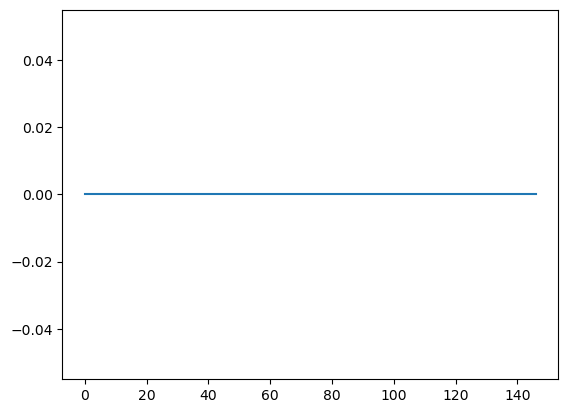

In [37]:
results['risk_analyses']['scenario_000']['scenario_heat_hours'].plot()